# Method 3 Amplitude Prior Review

Human-review notebook for Stage 05. It inspects the empirical amplitude/depth prior, temperature scaling `P_c(T)`, weak correlation checks, and fainter sensitivity variants.

In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_workspace():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'trap_completeness_method3').exists():
            return candidate
    raise RuntimeError('Could not find repo root containing trap_completeness_method3')

root = find_workspace()
workspace = root / 'trap_completeness_method3'
cache = workspace / 'cache'

plt.rcParams['figure.dpi'] = 120
root, cache

(WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps'),
 WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/cache'))

In [8]:
with (cache / '05_amplitude_prior_summary.json').open() as f:
    summary = json.load(f)

pd.Series({
    'primary_good_fit_records': summary['counts']['primary_good_fit_records'],
    'primary_high_confidence_records': summary['counts']['primary_high_confidence_records'],
    'default_depth_prior_traps': summary['counts']['default_depth_prior_traps'],
    'fit_coeff_p95_over_p05': summary['required_checks']['fit_coeff_breadth']['p95_over_p05'],
    'max_abs_trap_depth_rho': summary['required_checks']['rank_correlations_reported']['max_abs_trap_depth_rho_vs_E_tau_tau135'],
    'pc_210_over_pc_135': summary['pc_temperature_scaling']['warm_to_135_ratio_210K'],
})

primary_good_fit_records           15233.000000
primary_high_confidence_records    13963.000000
default_depth_prior_traps           2135.000000
fit_coeff_p95_over_p05                 2.888544
max_abs_trap_depth_rho                 0.150126
pc_210_over_pc_135                     0.680781
dtype: float64

## Prior Arrays

The default prior is conditional on detected, high-confidence records. The fainter variants are sensitivity tests, not inferred hidden-population measurements.

In [9]:
prior = np.load(cache / '05_amplitude_prior_v1.npz')
print(prior.files)

depth_keys = [key for key in prior.files if 'depth' in key.lower()]
for key in depth_keys:
    values = prior[key]
    print(key, values.shape, np.nanmedian(values), np.nanpercentile(values, [5, 16, 84, 95]))

['producing_stage', 'n_pumps', 'reference_temperature_K', 'temperatures_K', 'pc_temperature_factor', 'pc_temperature_record_count', 'default_depth_electrons_at_pc135', 'faint_0p5_depth_electrons_at_pc135', 'faint_0p25_depth_electrons_at_pc135', 'observed_high_conf_amplitude_electrons', 'observed_high_conf_temperature_K', 'trap_ids', 'variant_names']
default_depth_electrons_at_pc135 (2135,) 2511.6062765824763 [1367.86523003 1588.88939842 2954.54488454 3206.87119337]
faint_0p5_depth_electrons_at_pc135 (2135,) 1255.8031382912382 [ 683.93261502  794.44469921 1477.27244227 1603.43559669]
faint_0p25_depth_electrons_at_pc135 (2135,) 627.9015691456191 [341.96630751 397.22234961 738.63622114 801.71779834]


C:\Users\Ansh\AppData\Local\Temp\ipykernel_130992\4124965351.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


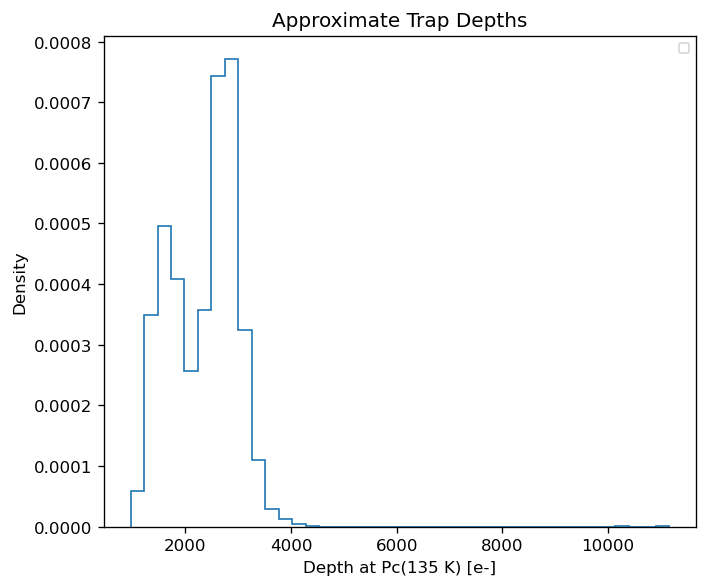

In [21]:
candidate_keys = [
    'default_depth_electrons_at_pc135',
    # 'faint_0p5_depth_electrons_at_pc135',
    # 'faint_0p25_depth_electrons_at_pc135',
]
available_keys = [key for key in candidate_keys if key in prior.files]

fig, ax = plt.subplots(figsize=(6,5))
for key in available_keys:
    values = np.asarray(prior[key], dtype=float)
    ax.hist(values, bins=40, histtype='step', density=True)
ax.set_xlabel('Depth at Pc(135 K) [e-]')
ax.set_ylabel('Density')
ax.set_title('Approximate Trap Depths')
ax.legend(fontsize=8)
fig.tight_layout()

## Temperature Scaling

,temperature_K,pc_factor
0,125.0,0.911426
1,130.0,0.962079
2,135.0,1.000000
3,140.0,1.002509
4,145.0,1.074208
5,150.0,1.108496
6,155.0,1.108633
7,160.0,1.261525
8,165.0,1.097882
9,170.0,1.239461


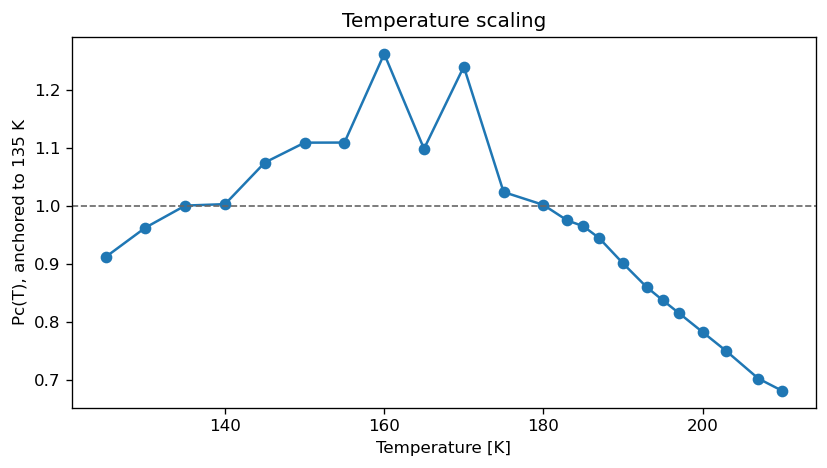

In [11]:
pc = summary['pc_temperature_scaling']['pc_temperature_factor']
pc_df = pd.DataFrame({'temperature_K': [float(k) for k in pc], 'pc_factor': list(pc.values())}).sort_values('temperature_K')
display(pc_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pc_df['temperature_K'], pc_df['pc_factor'], marker='o')
ax.axhline(1.0, color='0.4', linewidth=1, linestyle='--')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Pc(T), anchored to 135 K')
ax.set_title('Temperature scaling')
fig.tight_layout()

## Correlation Checks

,group,target,rho,p_value,n
0,observation_log_amplitude_primary_good_fit,vs_E_eV,0.068109,3.921493e-17,15233
1,observation_log_amplitude_primary_good_fit,vs_log_fit_tau,0.151521,6.472201e-79,15233
2,observation_log_amplitude_primary_good_fit,vs_log_tau_135,0.082818,1.335719e-24,15233
3,observation_log_depth_high_confidence,vs_E_eV,0.149024,3.713059e-70,13963
4,observation_log_depth_high_confidence,vs_log_fit_tau,0.026397,1.811461e-03,13963
5,observation_log_depth_high_confidence,vs_log_tau_135,0.158055,8.589011e-79,13963
6,trap_log_depth_high_confidence,vs_E_eV,0.138568,1.276141e-10,2135
7,trap_log_depth_high_confidence,vs_log_median_fit_tau,0.082227,1.426032e-04,2135
8,trap_log_depth_high_confidence,vs_log_tau_135,0.150126,3.119660e-12,2135


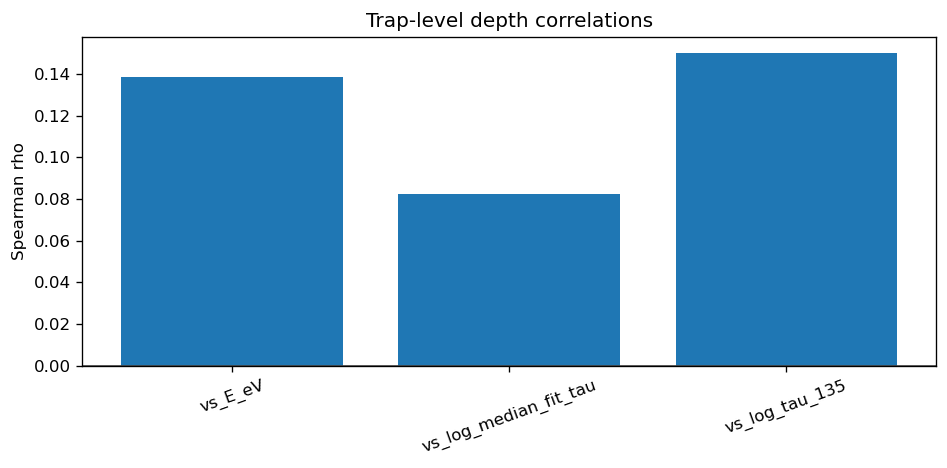

In [12]:
rows = []
for group_name, group in summary['correlations'].items():
    for target, stats in group.items():
        if target == 'value_key':
            continue
        rows.append({
            'group': group_name,
            'target': target,
            'rho': stats['rho'],
            'p_value': stats['p_value'],
            'n': stats['n'],
        })
corr_df = pd.DataFrame(rows)
display(corr_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = corr_df[corr_df['group'] == 'trap_log_depth_high_confidence']
ax.bar(plot_df['target'], plot_df['rho'])
ax.axhline(0, color='0.3', linewidth=1)
ax.set_ylabel('Spearman rho')
ax.set_title('Trap-level depth correlations')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()

## Existing Stage 05 Figures

C:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\figures\05_depth_prior_hist.png


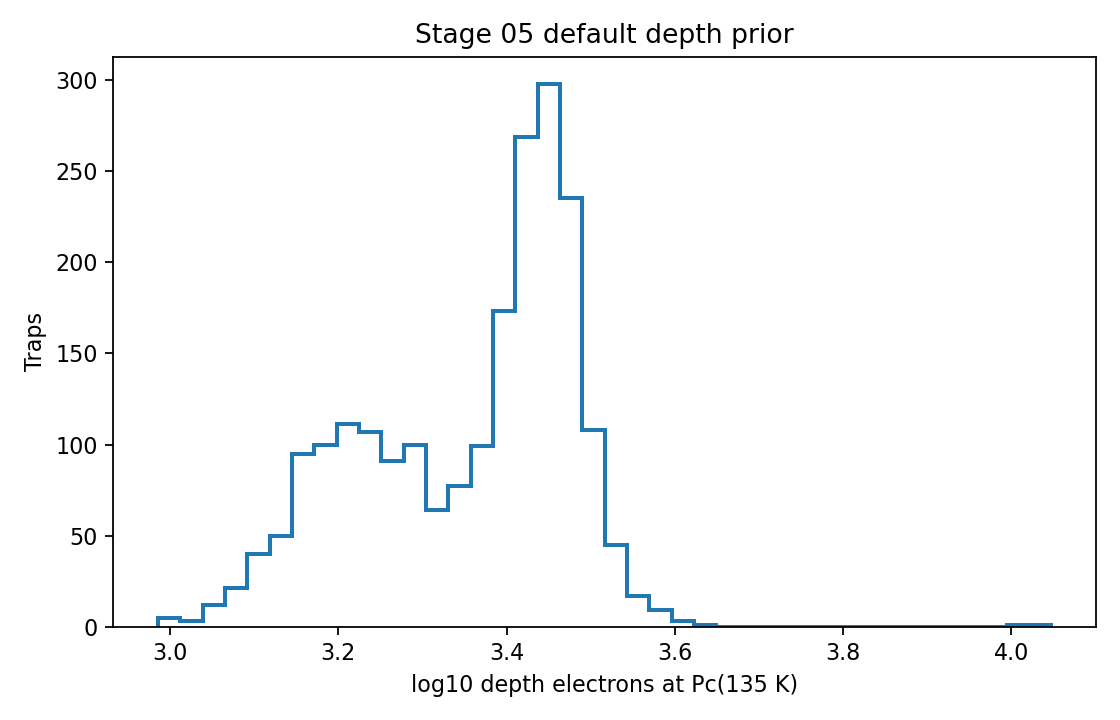

C:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\figures\05_pc_temperature_scaling.png


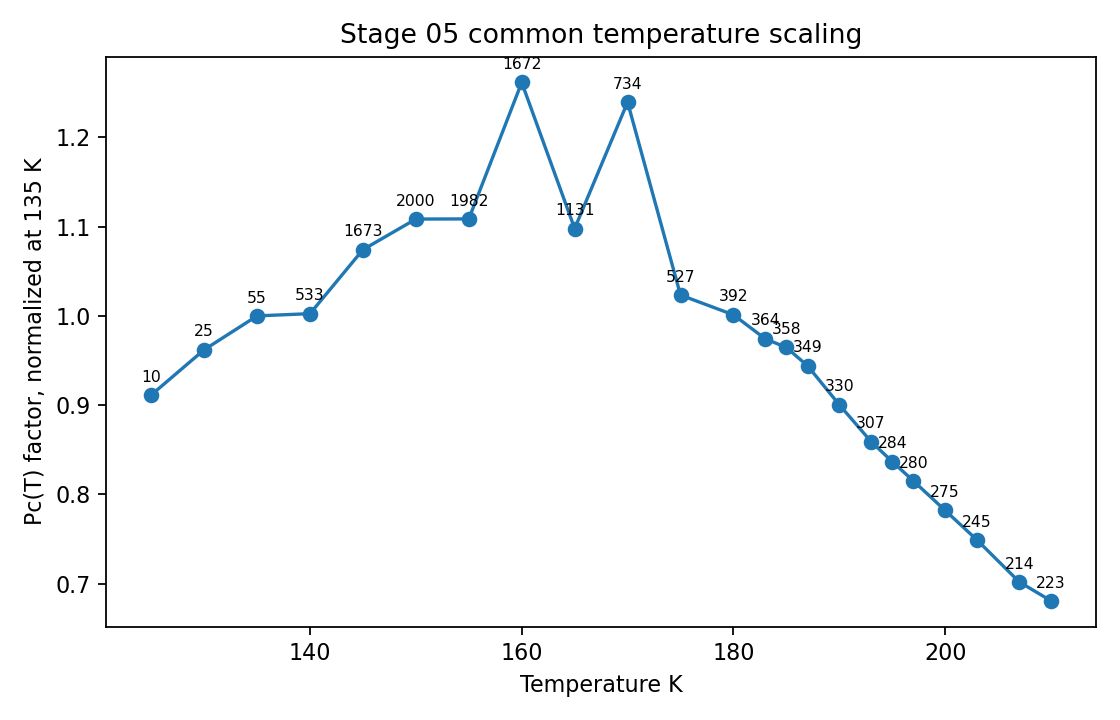

In [13]:
from IPython.display import Image, display

for name in ['05_depth_prior_hist.png', '05_pc_temperature_scaling.png']:
    path = cache / 'figures' / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))